In [ ]:
!pip install diffusers transformers accelerate peft safetensors datasets torchvision librosa soundfile pillow


In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
!git clone https://github.com/votaquangnhat/music-timbre-transfer.git

Cloning into 'music-timbre-transfer'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 40 (delta 12), reused 39 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 191.69 KiB | 8.33 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
import torch

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No CUDA-enabled GPU detected.")

CUDA version: 12.8
GPU count: 1
Current GPU: 0
GPU name: Tesla T4


In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

In [ ]:
from pathlib import Path
from huggingface_hub import snapshot_download

PROJECT_DIR = Path("/content/music-timbre-transfer")  # change this if your repo folder has another name
%cd {PROJECT_DIR}

DATA_DIR = PROJECT_DIR / "data"
SPECTRORGRAMS_DIR = DATA_DIR / "spectrogram"
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAR_PATH = Path("/content/drive/MyDrive/project2/spectrogram.rar")

# Mount Google Drive if not mounted
from google.colab import drive
drive.mount("/content/drive")

# Install unrar
!apt-get -qq install -y unrar

# Check file exists
assert RAR_PATH.exists(), f"File not found: {RAR_PATH}"

# Extract spectrogram.rar into DATA_DIR
!unrar x -o+ "{RAR_PATH}" "{DATA_DIR}/"

print("Dataset extracted to:", DATA_DIR)
!find "{DATA_DIR}" -maxdepth 2 -type f | head

/content/music-timbre-transfer
Mounted at /content/drive

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/project2/spectrogram.rar

Creating    /content/music-timbre-transfer/data/spectrogram           OK
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_725_slice_47_flute.npy       0%  OK 
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_144_slice_9_guitar.npy       0%  OK 
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_812_slice_44_piano.npy       0%  OK 
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_534_slice_31_piano.npy       0%  OK 
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_16_slice_43_flute.npy       0%  OK 
Extracting  /content/music-timbre-transfer/data/spectrogram/spectrogram_582_slice_32_guitar.npy       0%  OK 
Extracting  /content/

In [ ]:
from huggingface_hub import snapshot_download

MODEL_DIR = PROJECT_DIR / "models" / "riffusion-model-v1"

snapshot_download(
    repo_id="riffusion/riffusion-model-v1",
    local_dir=str(MODEL_DIR),
)

print("Riffusion model saved to:", MODEL_DIR)
!ls -lah "{MODEL_DIR}" | head


Fetching 61 files:   0%|          | 0/61 [00:00<?, ?it/s]

Riffusion model saved to: /content/music-timbre-transfer/models/riffusion-model-v1
total 14G
drwxr-xr-x 12 root root 4.0K Jun 22 03:34 .
drwxr-xr-x  3 root root 4.0K Jun 22 03:23 ..
drwxr-xr-x  3 root root 4.0K Jun 22 03:23 .cache
drwxr-xr-x  2 root root 4.0K Jun 22 03:23 feature_extractor
-rw-r--r--  1 root root 1.5K Jun 22 03:23 .gitattributes
-rw-r--r--  1 root root  541 Jun 22 03:23 model_index.json
-rw-r--r--  1 root root 4.9K Jun 22 03:23 README.md
-rw-r--r--  1 root root  14G Jun 22 03:34 riffusion-model-v1.ckpt
drwxr-xr-x  2 root root 4.0K Jun 22 03:26 safety_checker


In [ ]:
TIMBRE = "guitar" # change to "piano", "guitar"
OUTPUT_DIR = PROJECT_DIR / "outputs" / f"test_lora_{TIMBRE}"

!mkdir -p "{OUTPUT_DIR}"

!accelerate launch src/train.py \
  --pretrained_model_name_or_path "{MODEL_DIR}" \
  --spectrograms_dir "{SPECTRORGRAMS_DIR}" \
  --timbre "{TIMBRE}" \
  --train_subset train \
  --validation_subset validation \
  --output_dir "{OUTPUT_DIR}" \
  --train_batch_size 1 \
  --gradient_accumulation_steps 4 \
  --max_train_steps 5000 \
  --rank 16 \
  --learning_rate 1e-4 \
  --mixed_precision fp16 \
  --gradient_checkpointing \
  --save_steps 500 \
  --validation_steps 500 \
  --validation_max_batches 8 \
  --max_validation_samples 0 \
  --checkpoint_limit 4 \
  --dataloader_num_workers 2 \
  --verify_files

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Audio processing utilities loaded.
Loading weights: 100% 196/196 [00:00<00:00, 20491.13it/s]
An error occurred while trying to fetch /content/music-timbre-transfer/models/riffusion-model-v1: Error no file named diffusion_pytorch_model.safetensors found in directory /content/music-timbre-transfer/models/riffusion-model

In [ ]:
# 4. Save checkpoint to Google Drive

from google.colab import drive
drive.mount("/content/drive")

string_path = f"/content/drive/MyDrive/riffusion_lora_checkpoints/test_lora_{TIMBRE}"
DRIVE_SAVE_DIR = Path(string_path)

!mkdir -p "{DRIVE_SAVE_DIR.parent}"
!rm -rf "{DRIVE_SAVE_DIR}"
!cp -r "{OUTPUT_DIR}" "{DRIVE_SAVE_DIR}"

print("Saved to:", DRIVE_SAVE_DIR)
!ls -lah "{DRIVE_SAVE_DIR}"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/riffusion_lora_checkpoints/test_lora_guitar
total 13M
drwx------ 2 root root 4.0K Jun 22 06:32 checkpoint-3500
drwx------ 2 root root 4.0K Jun 22 06:32 checkpoint-4000
drwx------ 2 root root 4.0K Jun 22 06:32 checkpoint-4500
drwx------ 2 root root 4.0K Jun 22 06:32 checkpoint-5000
-rw------- 1 root root 168K Jun 22 06:32 metrics.csv
-rw------- 1 root root  13M Jun 22 06:32 pytorch_lora_weights.safetensors
-rw------- 1 root root 1.2K Jun 22 06:32 training_args.json


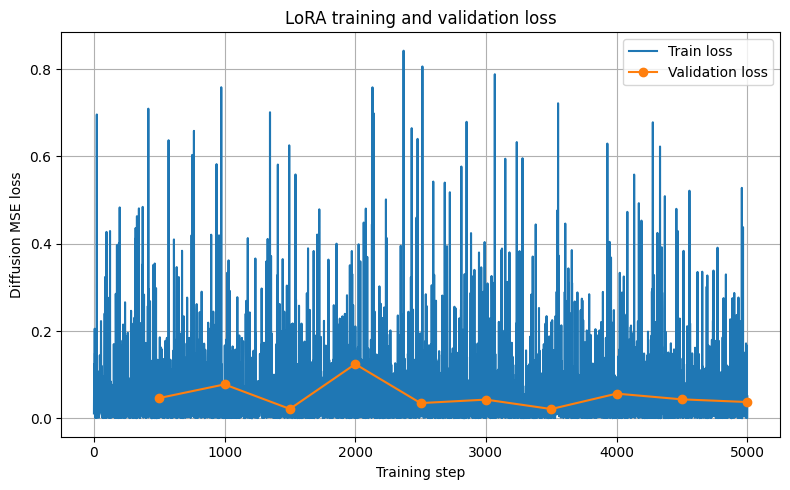

Saved plot to: /content/music-timbre-transfer/outputs/test_lora_guitar/loss_curve.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_path = f"{OUTPUT_DIR}/metrics.csv"
df = pd.read_csv(metrics_path)

train_df = df[df["train_loss"].notna()]
val_df = df[df["val_loss"].notna()]

plt.figure(figsize=(8, 5))
plt.plot(train_df["step"], train_df["train_loss"], label="Train loss")

if len(val_df) > 0:
    plt.plot(val_df["step"], val_df["val_loss"], marker="o", label="Validation loss")

plt.xlabel("Training step")
plt.ylabel("Diffusion MSE loss")
plt.title("LoRA training and validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = f"{OUTPUT_DIR}/loss_curve.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved plot to:", save_path)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Audio processing utilities loaded.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /content/music-timbre-transfer/models/riffusion-model-v1/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /content/music-timbre-transfer/models/riffusion-model-v1/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /content/music-timbre-transfer/models/riffusion-model-v1/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /content/music-timbre-transfer/models/riffusion-model-v1/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion_img2img.py:305: FutureWarning: The configuration file of the unet has set the default `sample_size` to smaller than 64 which seems highly unlikely. If your checkpoint is a fine-tuned version of any of the following: 
- CompVis/stable-diffu

  0%|          | 0/20 [00:00<?, ?it/s]

Saved inference image to: /content/music-timbre-transfer/outputs/test_lora_guitar/inference.png
Input:


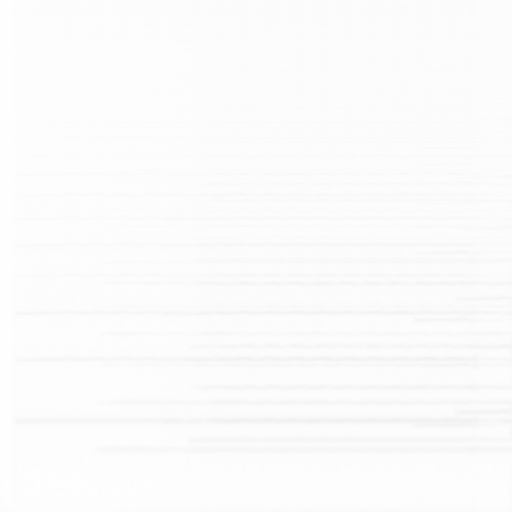

Output:


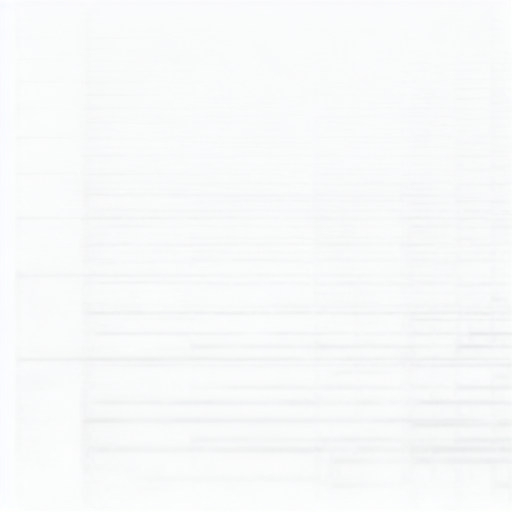

In [ ]:
# 5. Inference

import sys
sys.path.append(str(PROJECT_DIR / "src"))

import torch
import pandas as pd
import numpy as np
from IPython.display import display
from diffusers import StableDiffusionImg2ImgPipeline

from audio_wrapper import SpectrogramConverter

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

metadata = pd.read_csv(SPECTRORGRAMS_DIR / "spectrogram_metadata.csv")
row = metadata[metadata["timbres"] == "flute"].iloc[0] # take a piece of piano song

converter = SpectrogramConverter()
spectrogram = np.load(SPECTRORGRAMS_DIR / row["file_name"])
init_image = converter.image_from_spectrogram(spectrogram)

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    str(MODEL_DIR),
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

pipe.load_lora_weights(str(OUTPUT_DIR))

result = pipe(
    prompt="a mel spectrogram of solo flute music, same melody and rhythm",
    image=init_image,
    strength=0.4,
    guidance_scale=2.0,
    num_inference_steps=50,
    generator=torch.Generator(device=device).manual_seed(42),
).images[0]

INFER_PATH = OUTPUT_DIR / "inference.png"
result.save(INFER_PATH)

print("Saved inference image to:", INFER_PATH)

print("Input:")
display(init_image)

print("Output:")
display(result)


In [ ]:
# 6. Convert generated spectrogram image to audio
import soundfile as sf
from IPython.display import Audio, display

AUDIO_PATH = OUTPUT_DIR / "inference.wav"

# result is the generated PIL image from Cell 5
result_spectrogram = converter.spectrogram_from_image(result)

waveform = converter.waveform_from_spectrogram(
    result_spectrogram,
    device=device,
)

# normalize audio to avoid clipping
waveform = waveform / max(1e-8, abs(waveform).max())

sf.write(
    str(AUDIO_PATH),
    waveform,
    converter.sample_rate,
)

print("Saved audio to:", AUDIO_PATH)
display(Audio(str(AUDIO_PATH)))

Spectrogram shape from image: (512, 512)
Saved audio to: /content/music-timbre-transfer/outputs/test_lora_guitar/inference.wav
